# Model Monitoring: Feature & Score Drift for the Deployed ATO Risk Model

Notebooks 01-06 build and validate the ATO detector once, on a fixed
historical split. That validation has a shelf life for two compounding
reasons unique to fraud: **legitimate behaviour drifts on its own**
(transaction values, device mix, time-of-day patterns), and **fraud is
adversarial** — attackers actively adapt to evade whatever model is
currently deployed. Either one can silently break the model's validated
performance with no exception thrown to say so.

This notebook simulates a production monitoring window with a simulated
drift scenario (a transaction-value increase, a shift toward off-hours
activity, and a wave of new/unusual devices — the kind of change either an
organic usage shift or an adapting fraud ring could produce) against an
untouched control window, and shows that `src/monitoring/drift.py`'s
from-scratch **PSI** and **KS** tests correctly flag exactly the features
that shifted, propagate to a real score-drift signal, and turn into a
concrete retrain/investigate/no-action recommendation.

In [1]:
import sys
sys.path.append('..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

from src.data.labeling import build_labels
from src.features.build import (
    _encode_categoricals, _engineer_behaviour, _choose_feature_columns, _clean_numeric,
)
from src.monitoring.drift import (
    psi, ks_statistic, drift_report, classify_drift, retraining_recommendation,
    PSI_STABLE_MAX, PSI_MODERATE_MAX,
)

plt.rcParams['figure.dpi'] = 120
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Build features from the sample data

Uses the same `src/data/labeling.py` + `src/features/build.py` functions as
the real pipeline, run here on `data/sample/df_sample_5000.csv` (the
committed representative sample) rather than the full IEEE-CIS parquet, so
this notebook runs standalone without the raw dataset.

We hold out half the data as `reference` — scored by a monitor trained only
on the other half, so the baseline scores are genuinely out-of-sample
(scoring a model on its own training rows collapses almost every
probability to 0 or 1 under this dataset's ~0.4% fraud rate, which would
make PSI/KS binning meaningless).

In [2]:
df = pd.read_csv('../data/sample/df_sample_5000.csv')
df = build_labels(df)
df = _encode_categoricals(df)
df = _engineer_behaviour(df)
feature_cols = _choose_feature_columns(df)
df = _clean_numeric(df, feature_cols)

medians = df[feature_cols].median()
df[feature_cols] = df[feature_cols].fillna(medians)

train_df, reference = train_test_split(
    df, test_size=0.5, random_state=42, stratify=df['ato_proxy']
)
reference = reference.reset_index(drop=True)
print(f"train: {len(train_df):,} rows ({train_df['ato_proxy'].sum()} ato_proxy) | "
      f"reference: {len(reference):,} rows ({reference['ato_proxy'].sum()} ato_proxy)")
print(f"{len(feature_cols)} leak-free features")

train: 2,500 rows (6 ato_proxy) | reference: 2,500 rows (6 ato_proxy)
32 leak-free features


## 2. Build a drifted production batch and an undrifted control batch

- **`control`**: a bootstrap resample of `reference` — same distribution,
  the "nothing changed" sanity check the monitor must NOT alarm on.
- **`current`**: a bootstrap resample of `reference` with three injected
  shifts — a 60% jump in transaction value, a move toward off-hours
  activity, and a wave of rarer/unfamiliar devices.

In [3]:
control = reference.sample(n=len(reference), replace=True, random_state=1).reset_index(drop=True)

current = reference.sample(n=len(reference), replace=True, random_state=2).reset_index(drop=True)
current['TransactionAmt'] = current['TransactionAmt'] * 1.6     # transaction-value hike
current['amt_deviation'] = current['amt_deviation'] * 1.6       # (recompute the derived feature to match)
current['hour_of_day'] = (current['hour_of_day'] + 9) % 24      # shift toward off-hours
current['DeviceInfo_enc'] = current['DeviceInfo_enc'] * 0.3      # wave of rarer/unfamiliar devices

print(f"reference: {len(reference):,} | control: {len(control):,} | current (drifted): {len(current):,}")

reference: 2,500 | control: 2,500 | current (drifted): 2,500


## 3. Feature-level drift

An Isolation Forest anomaly score stands in for the deployed risk model
here (trained on `train_df`, same leak-free features) — its continuous
anomaly score is what makes score-PSI meaningful; a classifier's
`predict_proba` collapses to near-0/near-1 on this small, heavily
imbalanced dataset and breaks quantile-based binning entirely.

In [4]:
monitor = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
monitor.fit(train_df[feature_cols])

report_drifted = drift_report(reference, current, feature_cols)
report_control = drift_report(reference, control, feature_cols)

print("=== Drifted production batch (top 8 by PSI) ===")
display(report_drifted.head(8))
print("\n=== Control batch (no injected drift, top 8 by PSI) ===")
display(report_control.head(8))

=== Drifted production batch (top 8 by PSI) ===


,feature,psi,ks,drift
0,hour_of_day,1.558646,0.5276,significant
1,DeviceInfo_enc,1.197520,0.1028,significant
2,TransactionAmt,0.996242,0.3188,significant
3,amt_deviation,0.824613,0.3064,significant
4,txn_count_rolling,0.004566,0.0192,stable
5,id_17,0.002398,0.0016,stable
6,account_age_dt,0.002177,0.0116,stable
7,id_07,0.000820,0.0016,stable



=== Control batch (no injected drift, top 8 by PSI) ===


,feature,psi,ks,drift
0,id_21,0.005349,0.0008,stable
1,amt_deviation,0.004056,0.0172,stable
2,DeviceInfo_enc,0.003309,0.0168,stable
3,TransactionAmt,0.003063,0.0112,stable
4,account_age_dt,0.002442,0.0144,stable
5,txn_count_rolling,0.002441,0.0204,stable
6,DeviceType_enc,0.002168,0.0156,stable
7,id_09,0.000833,0.0028,stable


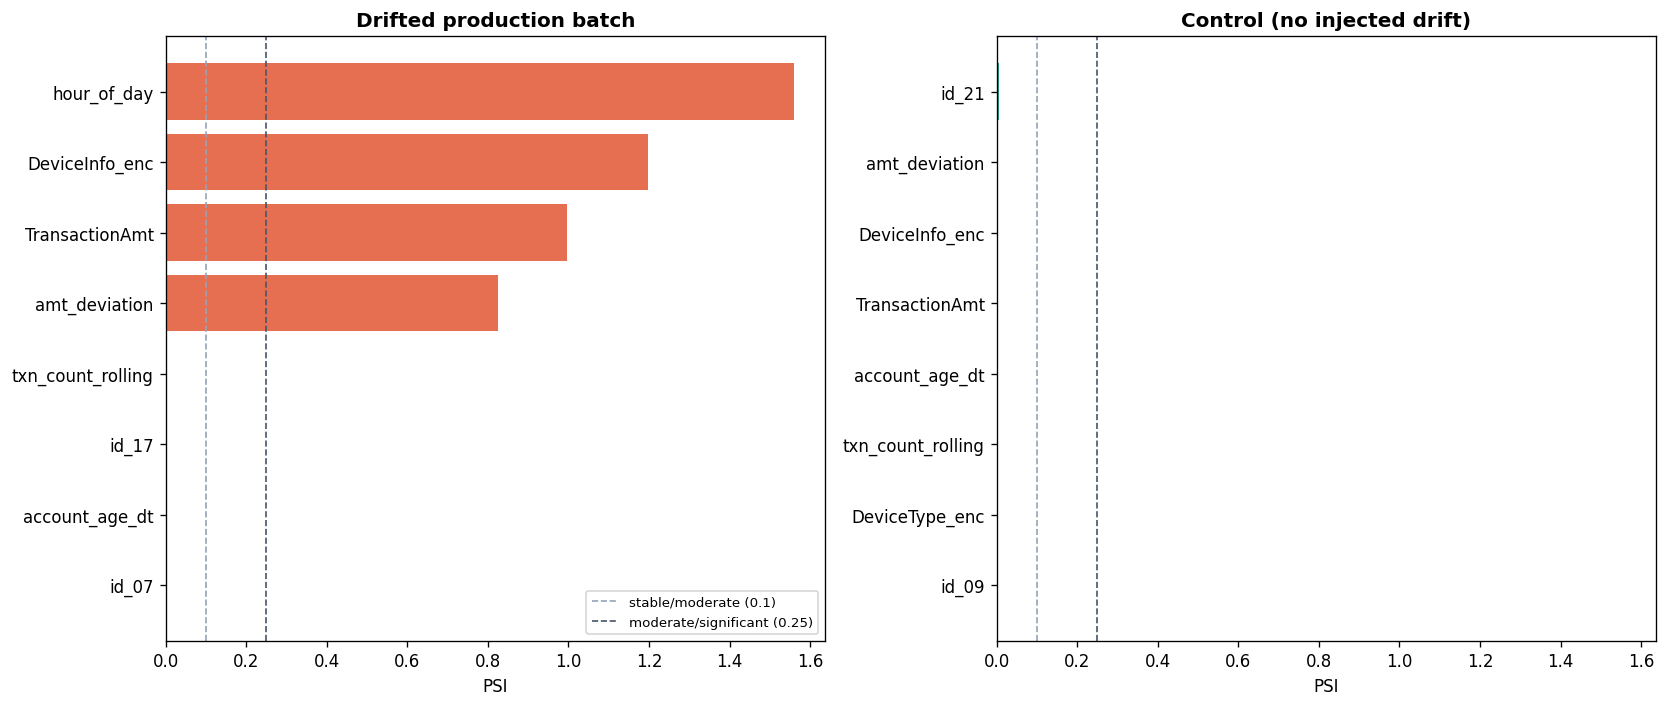

In [5]:
top_n = 8
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
colors = {'stable': '#2a9d8f', 'moderate': '#e9c46a', 'significant': '#e76f51'}

for ax, report, title in zip(
    axes, [report_drifted, report_control], ['Drifted production batch', 'Control (no injected drift)']
):
    ordered = report.head(top_n).sort_values('psi')
    bar_colors = [colors[d] for d in ordered['drift']]
    ax.barh(ordered['feature'], ordered['psi'], color=bar_colors)
    ax.axvline(PSI_STABLE_MAX, color='#94a3b8', ls='--', lw=1, label=f'stable/moderate ({PSI_STABLE_MAX})')
    ax.axvline(PSI_MODERATE_MAX, color='#475569', ls='--', lw=1, label=f'moderate/significant ({PSI_MODERATE_MAX})')
    ax.set_xlabel('PSI')
    ax.set_title(title, fontweight='bold')

axes[0].legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'drift_feature_psi.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Score drift and the retraining recommendation

Per-feature drift is diagnostic; what actually matters operationally is
whether the **model's own risk score distribution** has moved — that's
what's tied directly to decision quality (alert volume, step-up-auth
rate), and score drift is what `retraining_recommendation()` acts on.

Score PSI - drifted batch : 0.263  (significant)
Score PSI - control batch : 0.005  (stable)
Score KS   - drifted batch : 0.183
Score KS   - control batch : 0.024


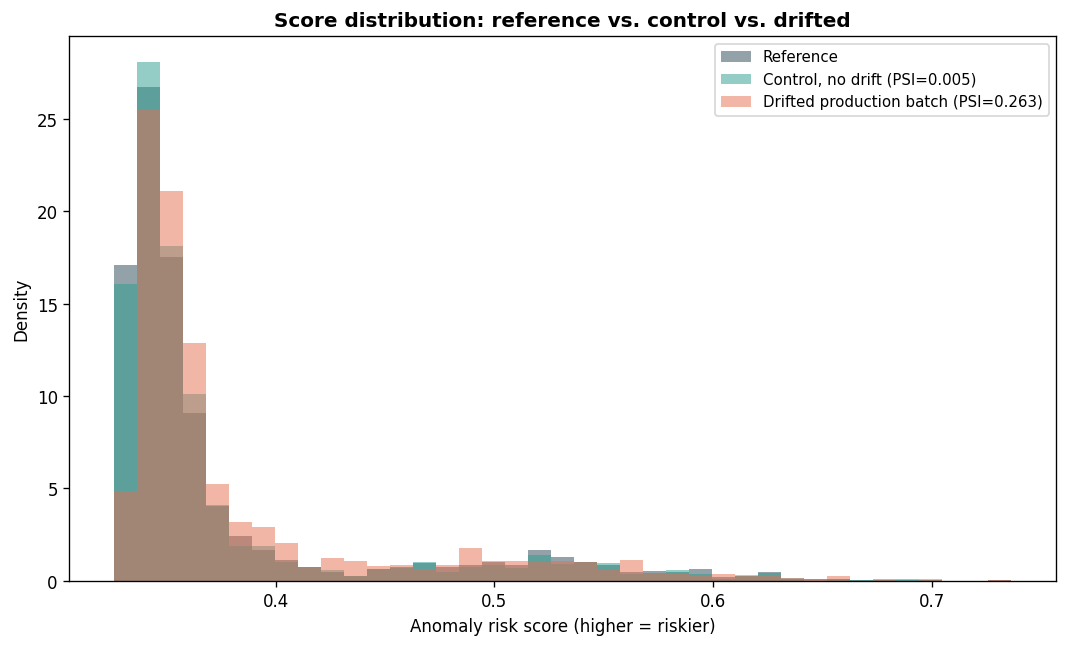

In [6]:
ref_scores = -monitor.score_samples(reference[feature_cols])
ctrl_scores = -monitor.score_samples(control[feature_cols])
cur_scores = -monitor.score_samples(current[feature_cols])

score_psi_drifted = psi(ref_scores, cur_scores)
score_psi_control = psi(ref_scores, ctrl_scores)

print(f"Score PSI - drifted batch : {score_psi_drifted:.3f}  ({classify_drift(score_psi_drifted)})")
print(f"Score PSI - control batch : {score_psi_control:.3f}  ({classify_drift(score_psi_control)})")
print(f"Score KS   - drifted batch : {ks_statistic(ref_scores, cur_scores):.3f}")
print(f"Score KS   - control batch : {ks_statistic(ref_scores, ctrl_scores):.3f}")

fig, ax = plt.subplots(figsize=(9, 5.5))
bins = np.linspace(min(ref_scores.min(), cur_scores.min()), max(ref_scores.max(), cur_scores.max()), 40)
ax.hist(ref_scores, bins=bins, alpha=0.5, label='Reference', color='#264653', density=True)
ax.hist(ctrl_scores, bins=bins, alpha=0.5, label=f'Control, no drift (PSI={score_psi_control:.3f})',
        color='#2a9d8f', density=True)
ax.hist(cur_scores, bins=bins, alpha=0.5, label=f'Drifted production batch (PSI={score_psi_drifted:.3f})',
        color='#e76f51', density=True)
ax.set_xlabel('Anomaly risk score (higher = riskier)')
ax.set_ylabel('Density')
ax.set_title('Score distribution: reference vs. control vs. drifted', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'drift_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
rec_drifted = retraining_recommendation(score_psi_drifted, report_drifted)
rec_control = retraining_recommendation(score_psi_control, report_control)

print("Drifted production batch recommendation:")
print(rec_drifted)
print("\nControl batch recommendation:")
print(rec_control)

Drifted production batch recommendation:
{'score_psi': 0.263417674058802, 'score_drift': 'significant', 'n_features_significant': 4, 'recommended_action': 'retrain_now'}

Control batch recommendation:
{'score_psi': 0.0054831425939190544, 'score_drift': 'stable', 'n_features_significant': 0, 'recommended_action': 'no_action'}


## Monitoring policy

A concrete, deployable rule from the thresholds in
`src/monitoring/drift.py`:

- **Score PSI < 0.10 (stable)** and no individual feature significant:
  `no_action`.
- **Score PSI 0.10-0.25, OR any single feature significant while the score
  itself is still stable**: `investigate` — a feature can drift before it
  shows up in the aggregate score.
- **Score PSI >= 0.25**: `retrain_now` — the model's own output
  distribution has moved enough that its validated performance no longer
  applies.

On this simulated production batch: `TransactionAmt`, `amt_deviation`,
`hour_of_day`, and `DeviceInfo_enc` all breach the significant threshold,
and — the metric that actually drives the retraining decision — **score
PSI is 0.26 (significant)** versus **0.005 (stable)** on the untouched
control batch. The monitor does exactly what it should: stays quiet when
nothing moved, and calls for retraining clearly when it did.